Train word2vec/GloVe on a small corpus; visualize
neighborhoods; intrinsic vs. extrinsic evaluation.

In [1]:
import re
from typing import List, Callable, Any, Dict
from datasets import load_dataset
from functorch.dim import softmax
from gensim.models import Word2Vec, KeyedVectors
from sklearn.metrics import f1_score, recall_score, precision_score
import gensim.downloader as api
import numpy as np
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

/Users/kirillgorunov/miniconda3/envs/nlp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Download dataset **ag_news**:

In [2]:
dataset = load_dataset("ag_news")

Select train & text:

In [3]:
train_text = dataset["train"]
test_text = dataset["test"]

Sample example:

we have text with new's title and description, and one of four labels

In [4]:
train_text[634]

{'text': 'Dodgers Rally in 8th to Defeat Cubs 8-5 (AP) AP - Adrian Beltre and Shawn Green homered, and Steve Finley hit a go-ahead RBI single in the eighth inning as the Los Angeles Dodgers rallied for an 8-5 victory over the Chicago Cubs on Sunday.',
 'label': 1}

Tokenize all train text:

In [5]:
def tokenize(text: str, pattern: str = None) -> List[str]:
    pattern = r"(?:\w+')\w+|(?:[A-Z]\.)+|\w+(?:-\w+)*|[\w+\.]"
    tokens = re.findall(pattern, text)
    return tokens

Tokenize train and test tokens

In [6]:
train_tokens = [tokenize(text_sample) for text_sample in list(train_text["text"])]
test_tokens = [tokenize(text_sample) for text_sample in list(test_text["text"])]

And get all tokens for training

In [7]:
all_tokens = train_tokens + test_tokens

First, we will train our model on **all corpus of text**:

Create Word2Vec model

In [8]:
model_w2v_locally_train_all_dataset = Word2Vec(
    vector_size=300,
    window=4,
    min_count=1,
    sg=1,
    epochs=2000,
    seed=42,
    workers=12,
    negative=6,
)
model_w2v_locally_train_all_dataset.build_vocab(all_tokens)

Train our Word2Vec model:

In [9]:
model_w2v_locally_train_all_dataset.train(
    corpus_iterable=all_tokens,
    total_examples=len(all_tokens),
    epochs=3,

) # (849832055, 1030897600) 10m

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


(12747759, 15463464)

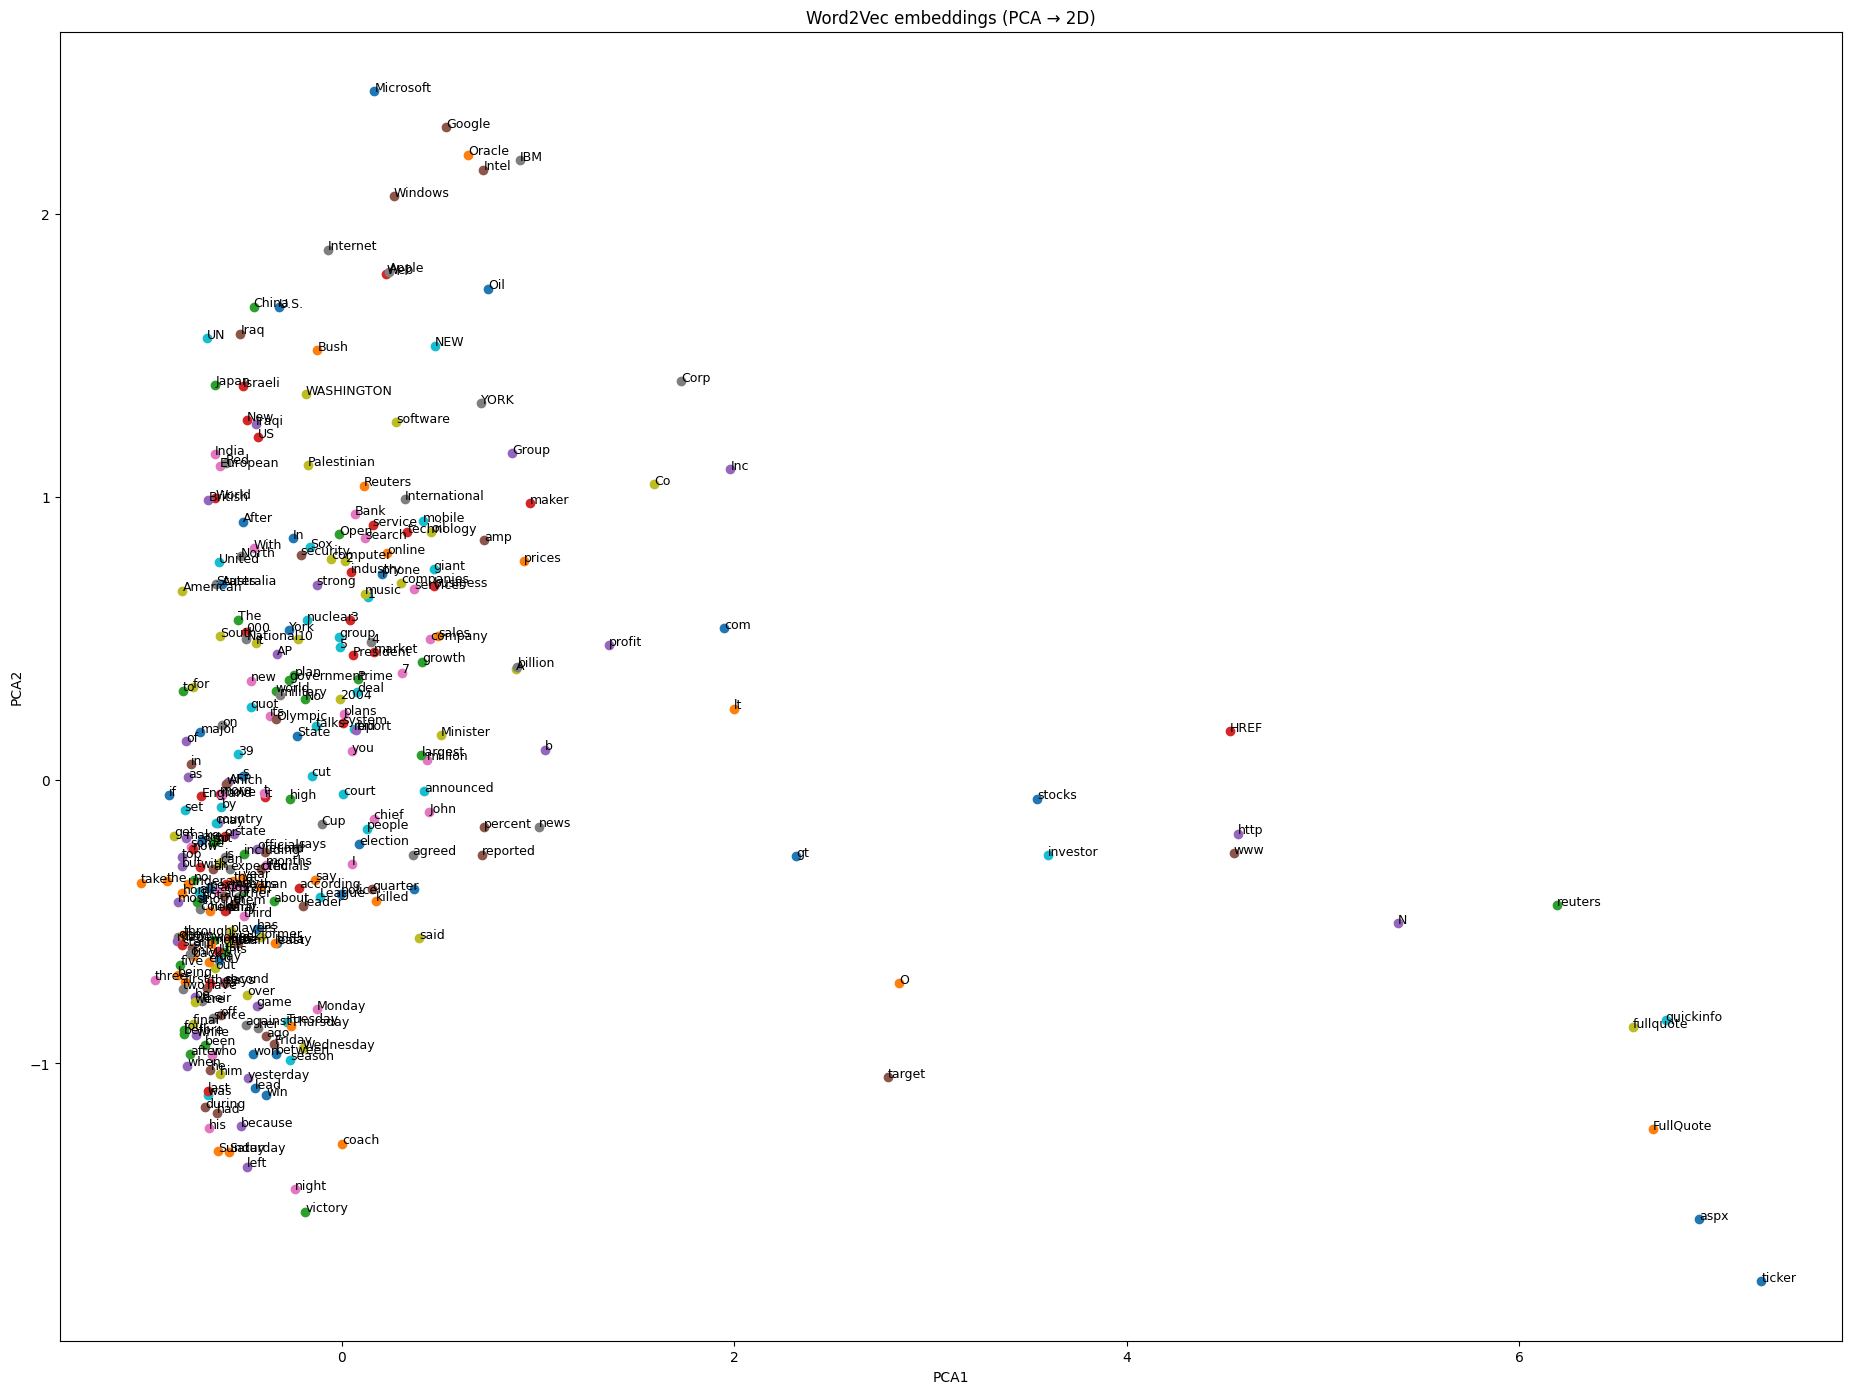

In [16]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

words = list(model_w2v_locally_train_all_dataset.wv.key_to_index.keys())[:300]
vectors = model_w2v_locally_train_all_dataset.wv[words]

pca = PCA(n_components=2)
coords = pca.fit_transform(vectors)

plt.figure(figsize=(23, 17))
for i, word in enumerate(words):
    plt.scatter(coords[i, 0], coords[i, 1])
    plt.annotate(word, (coords[i, 0], coords[i, 1]), fontsize=9)
plt.title("Word2Vec embeddings (PCA → 2D)")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()